In [12]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

processed_path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/splits/processed_data_02.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [13]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Ivar de SDSS
y_ivar_train = data["y_ivar_train"]
y_ivar_val = data["y_ivar_val"]
y_ivar_test = data["y_ivar_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

In [ ]:
def plot_random_examples(
    X,
    X_err,
    y,
    y_ivar,
    gaia_wavelength,
    sdss_wavelength,
    gaia_ID,
    sdss_ID,
    n_examples=5,
    seed=None
):
    rng = np.random.default_rng(seed)
    n_samples = X.shape[0]

    random_indices = rng.choice(
        n_samples,
        size=min(n_examples, n_samples),
        replace=False
    )

    for idx in random_indices:

        # Puntos válidos de SNR de gaia
        valid_gaia = (
            np.isfinite(X_err[idx])
            & (X_err[idx] > 0)
        )

        # Puntos válidos de SNR de SDSS
        valid_sdss = (
            np.isfinite(y_ivar[idx])
            & (y_ivar[idx] > 0)
        )

        # Cálculo del error de SDSS a partir de IVAR
        sdss_error = np.full(
            y[idx].shape,
            np.nan,
            dtype=float
        )

        sdss_error[valid_sdss] = (
            1.0 / np.sqrt(y_ivar[idx][valid_sdss])
        )

        gaia_snr = np.nanmedian(
            X[idx][valid_gaia]
            / X_err[idx][valid_gaia]
        )

        sdss_snr = np.nanmedian(
            y[idx][valid_sdss]
            * np.sqrt(y_ivar[idx][valid_sdss])
        )

        plt.figure(figsize=(11, 5))

        # Espectro SDSS
        plt.plot(
            sdss_wavelength[valid_sdss],
            y[idx][valid_sdss],
            label=f"SDSS — SNR: {sdss_snr:.2f}",
            linewidth=1.2
        )

        # Banda de error SDSS: flujo +- error
        plt.fill_between(
            sdss_wavelength[valid_sdss],
            y[idx][valid_sdss] - sdss_error[valid_sdss],
            y[idx][valid_sdss] + sdss_error[valid_sdss],
            alpha=0.20,
            label="Error SDSS"
        )

        # Espectro Gaia
        plt.plot(
            gaia_wavelength[valid_gaia],
            X[idx][valid_gaia],
            label=f"Gaia — SNR: {gaia_snr:.2f}",
            linewidth=1.2,
            alpha=0.8
        )

        # Banda de error Gaia: flujo +- error
        plt.fill_between(
            gaia_wavelength[valid_gaia],
            X[idx][valid_gaia] - X_err[idx][valid_gaia],
            X[idx][valid_gaia] + X_err[idx][valid_gaia],
            alpha=0.20,
            label="Error Gaia"
        )

        plt.xlabel("Longitud de onda [Å]")
        plt.ylabel("Flujo")

        plt.title(
            f"Gaia source_id: {gaia_ID[idx]} | "
            f"SDSS obj_id: {sdss_ID[idx]}\n"
            f"SNR Gaia: {gaia_snr:.2f} | "
            f"SNR SDSS: {sdss_snr:.2f}"
        )

        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return random_indices

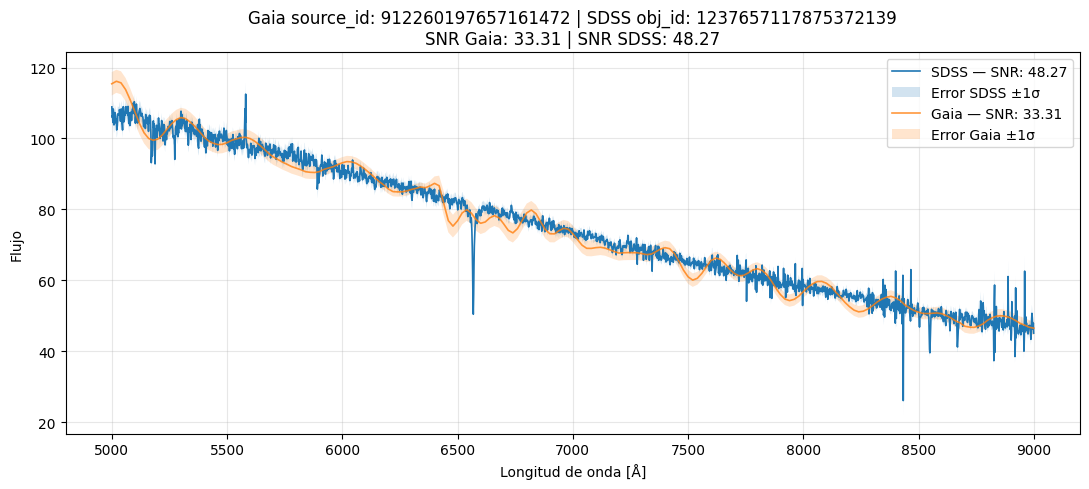

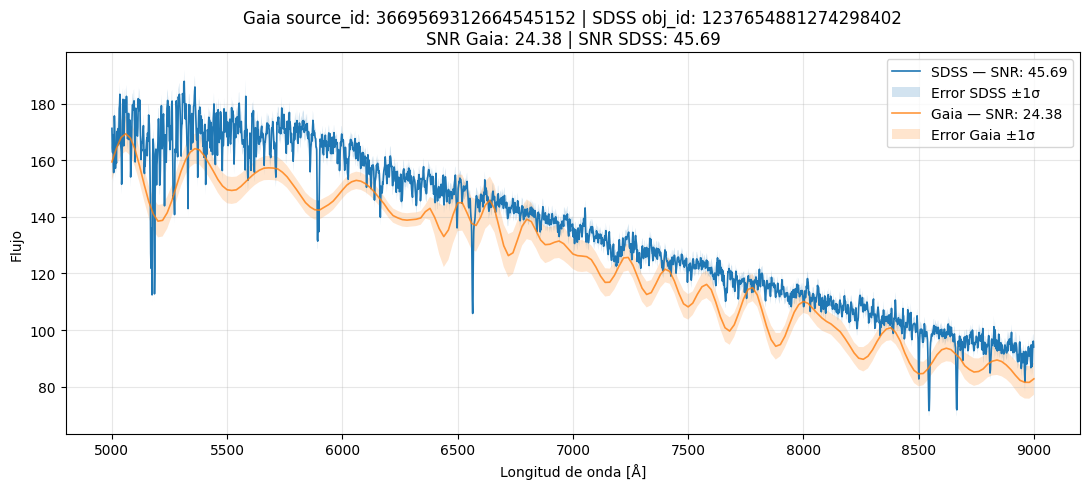

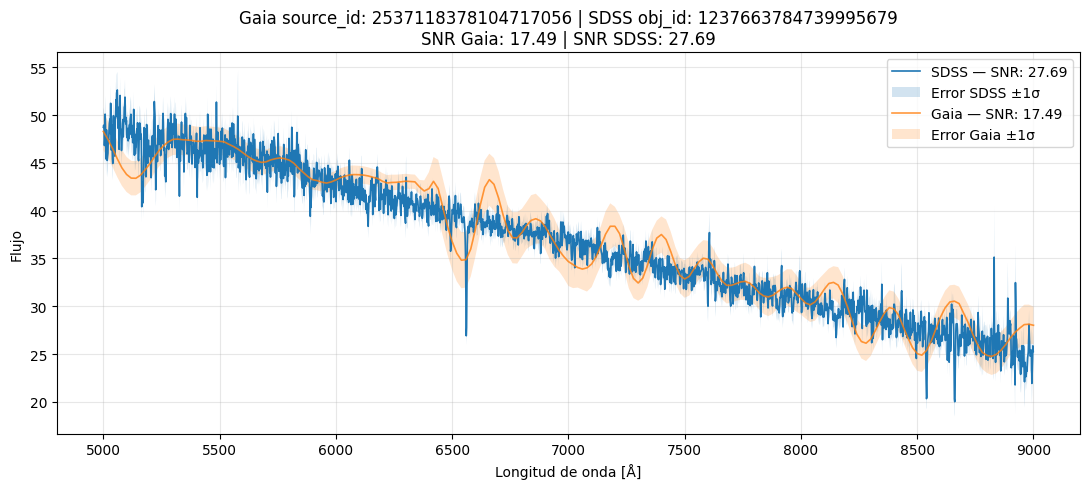

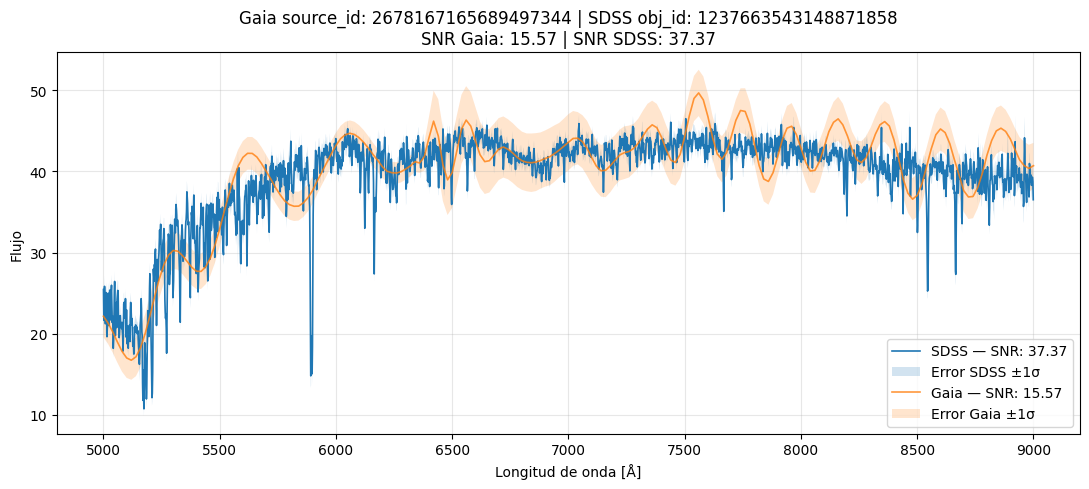

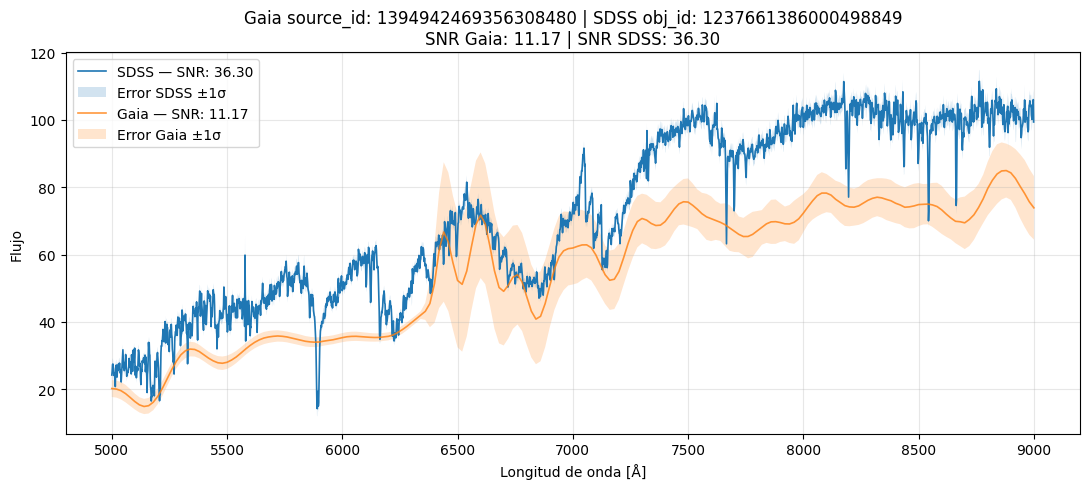

In [15]:
random_indices = plot_random_examples(
    X=X_test,
    X_err=X_err_test,
    y=y_test,
    y_ivar=y_ivar_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    gaia_ID=X_id_test,
    sdss_ID=y_id_test,
    n_examples=5,
    seed=42
)